In [264]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### Data Imports

In [329]:
# time series data
df_dur = pd.read_csv("../data/duration.csv")
df_ep = pd.read_csv("../data/e_price.csv")
df_occ = pd.read_csv("../data/occupancy.csv")
df_sp = pd.read_csv("../data/s_price.csv")
df_vol = pd.read_csv("../data/volume.csv")
# info + weather
inf  = pd.read_csv("../data/inf.csv")
w_airport = pd.read_csv("../data/weather_airport.csv")
w_central = pd.read_csv("../data/weather_central.csv")

### Data Pre-Processing

In [330]:
w_airport.rename(columns={w_airport.columns[0]: 'time'}, inplace=True)
w_central.rename(columns={w_central.columns[0]: 'time'}, inplace=True)

In [332]:
w_airport['time'] = pd.to_datetime(w_airport['time'])

C:\Users\anyak\AppData\Local\Temp\ipykernel_18532\3703222558.py:1: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  w_airport['time'] = pd.to_datetime(w_airport['time'])


In [334]:
w_airport = w_airport[::-1].reset_index(drop=True)

In [335]:
w_airport.head()

,time,T,P0,P,U,DD,Ff,ff10,WW,W'W',nRAIN,c,VV,Td
0,2022-09-01 00:00:00,28.0,755.9,756.2,89,Wind blowing from the north,2,NaN,NaN,NaN,0,No Significant Clouds,10.0 and more,26.0
1,2022-09-01 01:00:00,29.0,755.9,756.2,84,variable wind direction,1,NaN,NaN,NaN,0,No Significant Clouds,10.0 and more,26.0
2,2022-09-01 02:00:00,29.0,755.1,755.4,79,Wind blowing from the north-east,4,NaN,NaN,NaN,0,Scattered clouds (40-50%) 1500 m,10.0 and more,25.0
3,2022-09-01 03:00:00,29.0,755.1,755.4,79,Wind blowing from the north-northeast,3,NaN,NaN,NaN,0,Scattered clouds (40-50%) 1500 m,10.0 and more,25.0
4,2022-09-01 04:00:00,28.0,755.1,755.4,84,Wind blowing from the north-east,2,NaN,NaN,NaN,0,No Significant Clouds,10.0 and more,25.0


In [336]:
w_airport = w_airport[(w_airport["time"] >= '2022-09-01') & (w_airport["time"] <= '2023-02-28')] 

In [339]:
full_range = pd.date_range(
    start=w_airport['time'].min(),
    end=w_airport['time'].max(),
    freq='h'
)

In [340]:
missing = full_range.difference(df['time'])

print(missing)

DatetimeIndex(['2022-09-01 00:00:00', '2022-09-01 01:00:00',
               '2022-09-01 02:00:00', '2022-09-01 03:00:00',
               '2022-09-01 04:00:00', '2022-09-01 05:00:00',
               '2022-09-01 06:00:00', '2022-09-01 07:00:00',
               '2022-09-01 08:00:00', '2022-09-01 09:00:00',
               ...
               '2023-02-27 15:00:00', '2023-02-27 16:00:00',
               '2023-02-27 17:00:00', '2023-02-27 18:00:00',
               '2023-02-27 19:00:00', '2023-02-27 20:00:00',
               '2023-02-27 21:00:00', '2023-02-27 22:00:00',
               '2023-02-27 23:00:00', '2023-02-28 00:00:00'],
              dtype='datetime64[ns]', length=4321, freq='h')


In [341]:
missing_days = pd.to_datetime(missing.date).unique()
print(missing_days)

DatetimeIndex(['2022-09-01', '2022-09-02', '2022-09-03', '2022-09-04',
               '2022-09-05', '2022-09-06', '2022-09-07', '2022-09-08',
               '2022-09-09', '2022-09-10',
               ...
               '2023-02-19', '2023-02-20', '2023-02-21', '2023-02-22',
               '2023-02-23', '2023-02-24', '2023-02-25', '2023-02-26',
               '2023-02-27', '2023-02-28'],
              dtype='datetime64[ns]', length=181, freq=None)


In [337]:
w_airport

,time,T,P0,P,U,DD,Ff,ff10,WW,W'W',nRAIN,c,VV,Td
0,2022-09-01 00:00:00,28.0,755.9,756.2,89,Wind blowing from the north,2,NaN,NaN,NaN,0,No Significant Clouds,10.0 and more,26.0
1,2022-09-01 01:00:00,29.0,755.9,756.2,84,variable wind direction,1,NaN,NaN,NaN,0,No Significant Clouds,10.0 and more,26.0
2,2022-09-01 02:00:00,29.0,755.1,755.4,79,Wind blowing from the north-east,4,NaN,NaN,NaN,0,Scattered clouds (40-50%) 1500 m,10.0 and more,25.0
3,2022-09-01 03:00:00,29.0,755.1,755.4,79,Wind blowing from the north-northeast,3,NaN,NaN,NaN,0,Scattered clouds (40-50%) 1500 m,10.0 and more,25.0
4,2022-09-01 04:00:00,28.0,755.1,755.4,84,Wind blowing from the north-east,2,NaN,NaN,NaN,0,No Significant Clouds,10.0 and more,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4314,2023-02-27 20:00:00,17.0,768.5,768.9,64,Wind blowing from the south-southeast,4,NaN,NaN,NaN,0,No Significant Clouds,10.0 and more,10.0
4315,2023-02-27 21:00:00,17.0,768.5,768.9,56,Wind blowing from the east-southeast,5,NaN,NaN,NaN,0,No Significant Clouds,10.0 and more,8.0
4316,2023-02-27 22:00:00,16.0,769.2,769.6,63,Wind blowing from the east-southeast,5,NaN,NaN,NaN,0,No Significant Clouds,10.0 and more,9.0
4317,2023-02-27 23:00:00,16.0,769.2,769.6,68,Wind blowing from the east-southeast,5,NaN,NaN,NaN,0,No Significant Clouds,10.0 and more,10.0


In [267]:
inf['station_id'] = inf['station_id'].astype(str)
cap = inf.set_index('station_id')['pile_count'] 

occ_rate = df_occ.copy()
for station in occ_rate.columns:
    if station in cap.index:
        occ_rate[station] = occ_rate[station] / cap[station]
occ_rate.head()

,time,1001,1002,1003,1004,1005,1006,1007,1008,1009,...,2673,2674,2675,2676,2677,2678,2679,2680,2681,2682
0,2022-09-01 00:00:00,0.20,0.409091,0.333333,0.909091,0.454545,0.4,0.0,0.454545,0.500000,...,0.444444,0.25,0.4,0.555556,0.500000,0.0,0.333333,0.166667,0.2,0.0
1,2022-09-01 01:00:00,0.35,0.272727,0.333333,0.545455,0.454545,0.7,0.0,0.431818,0.652778,...,0.694444,0.50,1.0,0.666667,0.583333,0.0,0.250000,0.250000,0.3,0.0
2,2022-09-01 02:00:00,0.35,0.136364,0.166667,0.909091,0.454545,0.8,0.0,0.454545,0.833333,...,0.472222,0.25,0.0,0.555556,0.666667,0.0,0.583333,0.250000,0.1,0.0
3,2022-09-01 03:00:00,0.40,0.136364,0.166667,0.909091,0.454545,0.8,0.0,0.454545,0.805556,...,0.472222,0.25,1.0,0.555556,0.666667,0.0,0.583333,0.250000,0.1,0.0
4,2022-09-01 04:00:00,0.30,0.272727,0.333333,0.727273,0.454545,0.7,0.0,0.431818,0.750000,...,0.694444,0.50,1.0,0.555556,0.583333,0.0,0.250000,0.250000,0.2,0.0


In [268]:
import re

def parse_wind_direction(dd_series):
    """Convert text wind direction to sine/cosine of bearing degrees."""
    direction_map = {
        'north':            0,
        'north-northeast':  22.5,
        'northeast':        45,
        'east-northeast':   67.5,
        'east':             90,
        'east-southeast':   112.5,
        'southeast':        135,
        'south-southeast':  157.5,
        'south':            180,
        'south-southwest':  202.5,
        'southwest':        225,
        'west-southwest':   247.5,
        'west':             270,
        'west-northwest':   292.5,
        'northwest':        315,
        'north-northwest':  337.5,
        'calm':             0,  # no wind
    }
    def extract_bearing(text):
        if pd.isna(text):
            return np.nan
        text = text.lower()
        # strip "wind blowing from the " prefix
        text = re.sub(r'wind blowing from the\s*', '', text).strip()
        return direction_map.get(text, np.nan)

    bearings = dd_series.apply(extract_bearing)
    rad = np.deg2rad(bearings)
    return np.sin(rad), np.cos(rad)


def parse_rain(ww_series):
    """Binary: 1 if any rain/shower/drizzle mentioned."""
    rain_keywords = ['rain', 'shower', 'drizzle', 'thunderstorm', 'precipitation']
    def is_rain(text):
        if pd.isna(text):
            return 0
        return int(any(kw in str(text).lower() for kw in rain_keywords))
    return ww_series.apply(is_rain)


def parse_cloud_cover(c_series):
    """Map cloud description to ordinal 0–4 scale."""
    def cloud_ordinal(text):
        if pd.isna(text):
            return np.nan
        text = str(text).lower()
        if 'no significant' in text or 'clear' in text:
            return 0
        elif 'few' in text:          # 10–30%
            return 1
        elif 'scattered' in text:    # 40–50%
            return 2
        elif 'broken' in text:       # 60–90%
            return 3
        elif 'overcast' in text:     # 100%
            return 4
        return np.nan
    return c_series.apply(cloud_ordinal)


def parse_visibility(vv_series):
    """Convert visibility to numeric km; '10.0 and more' → 10.0."""
    def to_numeric(text):
        if pd.isna(text):
            return np.nan
        text = str(text).lower().replace('and more', '').strip()
        try:
            return float(text)
        except ValueError:
            return np.nan
    return vv_series.apply(to_numeric)


def preprocess_weather(df, prefix):
    out = pd.DataFrame(index=df.index)

    def safe_col(name):
        return df[name] if name in df.columns else pd.Series(index=df.index)
        
    out['T']  = pd.to_numeric(df['T'],  errors='coerce')
    out['P']  = pd.to_numeric(df['P'],  errors='coerce')
    out['U']  = pd.to_numeric(df['U'],  errors='coerce')
    out['Ff'] = pd.to_numeric(df['Ff'], errors='coerce')
    out['Td'] = pd.to_numeric(df['Td'], errors='coerce')

    out['wind_sin'], out['wind_cos'] = parse_wind_direction(df['DD'])
    out['is_raining']  = parse_rain(df['WW'])
    out['cloud_cover'] = parse_cloud_cover(safe_col('c'))
    out['visibility']  = parse_visibility(df['VV'])

    out.columns = [f'{prefix}_{c}' for c in out.columns]
    return out

def load_weather(df, prefix):
    df.index = pd.to_datetime(df['time'], format='%d.%m.%Y %H:%M')
    df = df.drop(columns=['time'])
    df = df.sort_index()
    df = df[~df.index.duplicated(keep='first')]
    num_cols = ['T', 'P', 'U', 'Ff', 'Td']
    cat_cols = ['DD', 'WW', 'c', 'VV']

    num_cols = [col for col in num_cols if col in df.columns]
    cat_cols = [col for col in cat_cols if col in df.columns]
    
    df_num = df[num_cols].apply(pd.to_numeric, errors='coerce').resample('h').mean()
    df_cat = df[cat_cols].resample('h').first()

    df = pd.concat([df_num, df_cat], axis=1)

    return preprocess_weather(df, prefix)

w_airport = load_weather(w_airport, 'ap')
w_central = load_weather(w_central, 'ct')

weather = pd.concat([w_airport, w_central], axis=1)

In [269]:
weather.head()

,ap_T,ap_P,ap_U,ap_Ff,ap_Td,ap_wind_sin,ap_wind_cos,ap_is_raining,ap_cloud_cover,ap_visibility,ct_T,ct_P,ct_U,ct_Ff,ct_Td,ct_wind_sin,ct_wind_cos,ct_is_raining,ct_cloud_cover,ct_visibility
time,,,,,,,,,,,,,,,,,,,,
2022-09-01 00:00:00,28.0,756.2,89.0,2.0,26.0,0.000000,1.00000,0,0.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-01 01:00:00,29.0,756.2,84.0,1.0,26.0,NaN,NaN,0,0.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-01 02:00:00,29.0,755.4,79.0,4.0,25.0,NaN,NaN,0,2.0,10.0,27.3,756.1,87.0,1.0,24.9,-0.382683,0.92388,0.0,NaN,27.0
2022-09-01 03:00:00,29.0,755.4,79.0,3.0,25.0,0.382683,0.92388,0,2.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2022-09-01 04:00:00,28.0,755.4,84.0,2.0,25.0,NaN,NaN,0,0.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [270]:
print(weather.isnull().sum())
print(weather.shape)

ap_T                10
ap_P                10
ap_U                10
ap_Ff               10
ap_Td               10
ap_wind_sin       1612
ap_wind_cos       1612
ap_is_raining        0
ap_cloud_cover      10
ap_visibility       10
ct_T              5850
ct_P              5850
ct_U              5850
ct_Ff             5850
ct_Td             5850
ct_wind_sin       6494
ct_wind_cos       6494
ct_is_raining        2
ct_cloud_cover    8760
ct_visibility     5850
dtype: int64
(8760, 20)


In [271]:
weather = weather.fillna(weather.median())

In [272]:
weather.head()

,ap_T,ap_P,ap_U,ap_Ff,ap_Td,ap_wind_sin,ap_wind_cos,ap_is_raining,ap_cloud_cover,ap_visibility,ct_T,ct_P,ct_U,ct_Ff,ct_Td,ct_wind_sin,ct_wind_cos,ct_is_raining,ct_cloud_cover,ct_visibility
time,,,,,,,,,,,,,,,,,,,,
2022-09-01 00:00:00,28.0,756.2,89.0,2.0,26.0,0.000000e+00,1.000000e+00,0,0.0,10.0,24.6,759.7,77.0,2.0,20.2,0.382683,6.123234e-17,0.0,NaN,30.0
2022-09-01 01:00:00,29.0,756.2,84.0,1.0,26.0,1.224647e-16,-1.836970e-16,0,0.0,10.0,24.6,759.7,77.0,2.0,20.2,0.382683,6.123234e-17,0.0,NaN,30.0
2022-09-01 02:00:00,29.0,755.4,79.0,4.0,25.0,1.224647e-16,-1.836970e-16,0,2.0,10.0,27.3,756.1,87.0,1.0,24.9,-0.382683,9.238795e-01,0.0,NaN,27.0
2022-09-01 03:00:00,29.0,755.4,79.0,3.0,25.0,3.826834e-01,9.238795e-01,0,2.0,10.0,24.6,759.7,77.0,2.0,20.2,0.382683,6.123234e-17,0.0,NaN,30.0
2022-09-01 04:00:00,28.0,755.4,84.0,2.0,25.0,1.224647e-16,-1.836970e-16,0,0.0,10.0,24.6,759.7,77.0,2.0,20.2,0.382683,6.123234e-17,0.0,NaN,30.0


In [273]:
data = {
    'occ':      df_occ,        
    'occ_rate': occ_rate,  
    'dur':      df_dur,
    'vol':      df_vol,
    'ep':       df_ep,
    'sp':       df_sp,
    'weather':  weather,
    'inf':      inf.set_index('station_id'),
}
TIMESTAMPS = df_occ.index
STATIONS   = df_occ.columns.tolist()

print(f"Ready: {len(TIMESTAMPS)} hours × {len(STATIONS)} stations")

Ready: 4321 hours × 1683 stations


### EDA

In [274]:
ep = data['ep']   # electricity price
sp = data['sp']   # service price

In [275]:
def to_long(df, value_name):
    df = df.copy()
    return df.melt(
        id_vars='time',
        var_name='station_id',
        value_name=value_name
    )
    
ep_long = to_long(ep, 'electric_price')
sp_long = to_long(sp, 'service_price')

In [276]:
df_price = ep_long.merge(sp_long, on=['time', 'station_id'])

In [277]:
df_price

,time,station_id,electric_price,service_price
0,2022-09-01 00:00:00,1001,1.20,0.47
1,2022-09-01 01:00:00,1001,1.20,0.47
2,2022-09-01 02:00:00,1001,1.20,0.47
3,2022-09-01 03:00:00,1001,1.20,0.47
4,2022-09-01 04:00:00,1001,1.20,0.47
...,...,...,...,...
7267917,2023-02-27 20:00:00,2682,1.05,0.70
7267918,2023-02-27 21:00:00,2682,1.05,0.70
7267919,2023-02-27 22:00:00,2682,1.05,0.70
7267920,2023-02-27 23:00:00,2682,1.05,0.70


In [278]:
df_price['time'] = pd.to_datetime(df_price['time'])
df_price['hour'] = df_price['time'].dt.hour
df_price['day_of_week'] = df_price['time'].dt.dayofweek
df_price['is_weekend'] = df_price['day_of_week'].isin([5, 6]).astype(int)
df_price['month'] = df_price['time'].dt.month
df_price['day_name'] = df_price['time'].dt.day_name()

In [279]:
df_price[['service_price', 'electric_price']].corr()

,service_price,electric_price
service_price,1.000000,0.021803
electric_price,0.021803,1.000000


In [280]:
df_price['spread'] = df_price['service_price'] - df_price['electric_price']

In [281]:
hourly = df_price.groupby('hour')[['service_price', 'electric_price', 'spread']].mean()

hour_corr = df_price.groupby('hour').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

hour_corr

C:\Users\anyak\AppData\Local\Temp\ipykernel_18532\1706435465.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hour_corr = df_price.groupby('hour').apply(


hour
0    -0.040364
1    -0.074633
2    -0.075171
3    -0.075739
4    -0.075905
5    -0.076495
6    -0.078006
7    -0.017034
8     0.064502
9     0.080021
10    0.059725
11    0.042082
12    0.077468
13    0.093045
14    0.061898
15    0.035612
16    0.034521
17    0.025940
18    0.022997
19    0.114183
20    0.133584
21    0.187617
22    0.194672
23    0.166746
dtype: float64

In [282]:
weekend_stats = df_price.groupby('is_weekend')[['service_price', 'electric_price', 'spread']].mean()

weekend_corr = df_price.groupby('is_weekend').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

weekend_corr

C:\Users\anyak\AppData\Local\Temp\ipykernel_18532\3660261719.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekend_corr = df_price.groupby('is_weekend').apply(


is_weekend
0    0.021518
1    0.022503
dtype: float64

In [283]:
dow_stats = df_price.groupby('day_name')[['service_price', 'electric_price', 'spread']].mean()

dow_corr = df_price.groupby('day_name').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

dow_corr

C:\Users\anyak\AppData\Local\Temp\ipykernel_18532\1172681204.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dow_corr = df_price.groupby('day_name').apply(


day_name
Friday       0.022134
Monday       0.021975
Saturday     0.023342
Sunday       0.021667
Thursday     0.022731
Tuesday      0.020172
Wednesday    0.020498
dtype: float64

In [284]:
month_stats = df_price.groupby('month')[['service_price', 'electric_price', 'spread']].mean()

month_corr = df_price.groupby('month').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

month_corr

C:\Users\anyak\AppData\Local\Temp\ipykernel_18532\2396688001.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  month_corr = df_price.groupby('month').apply(


month
1     0.011207
2     0.008312
9     0.023657
10    0.030774
11    0.028953
12    0.026952
dtype: float64

In [285]:
station_corr = df_price.groupby('station_id').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

station_spread = df_price.groupby('station_id')['spread'].mean()

station_corr

C:\Users\anyak\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\anyak\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\anyak\AppData\Local\Temp\ipykernel_18532\4144238744.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  station_corr = df_price.groupby('station_id').apply(


station_id
1001         NaN
1002         NaN
1003         NaN
1004   -0.896698
1005   -0.772263
          ...   
2678         NaN
2679         NaN
2680         NaN
2681         NaN
2682         NaN
Length: 1682, dtype: float64

In [286]:
station_spread

station_id
1001   -0.730000
1002   -0.340000
1003   -0.340000
1004   -0.147207
1005   -0.443198
          ...   
2678    0.511585
2679    0.040000
2680    0.040000
2681   -0.480000
2682   -0.350000
Name: spread, Length: 1682, dtype: float64

In [287]:
occ_rate_flat = data['occ_rate'].copy()
occ_rate_flat['time'] = pd.to_datetime(occ_rate_flat['time'])
occ_rate_flat['hour'] = occ_rate_flat['time'].dt.hour
occ_rate_flat['dow'] = occ_rate_flat['time'].dt.dayofweek
occ_rate_flat['is_weekend'] = occ_rate_flat['dow'].isin([5, 6]).astype(int)
occ_rate_flat['month'] = occ_rate_flat['time'].dt.month

In [288]:
occ_rate_flat = occ_rate_flat.drop('time',axis=1)

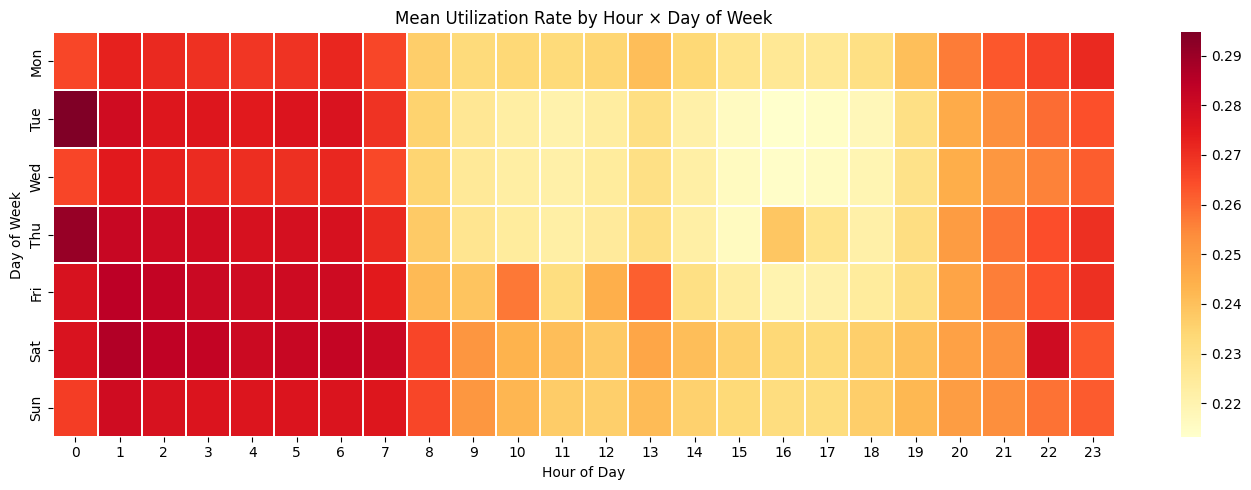

In [289]:
heatmap_data = occ_rate_flat.groupby(['dow', 'hour']).mean().mean(axis=1).unstack()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
)
ax.set_title('Mean Utilization Rate by Hour × Day of Week')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
#plt.savefig('demand_heatmap.png', dpi=150)
plt.show()

In [290]:
occ_mean['average_occupancy'] = data['occ'].iloc[:, 1:].mean(axis=1)
occ_mean['time'] = pd.to_datetime(data['occ']['time'])
occ_mean['hour'] = occ_mean['time'].dt.hour
occ_mean['dow'] = occ_mean['time'].dt.dayofweek
occ_mean['is_weekend'] = occ_mean['dow'].isin([5, 6]).astype(int)

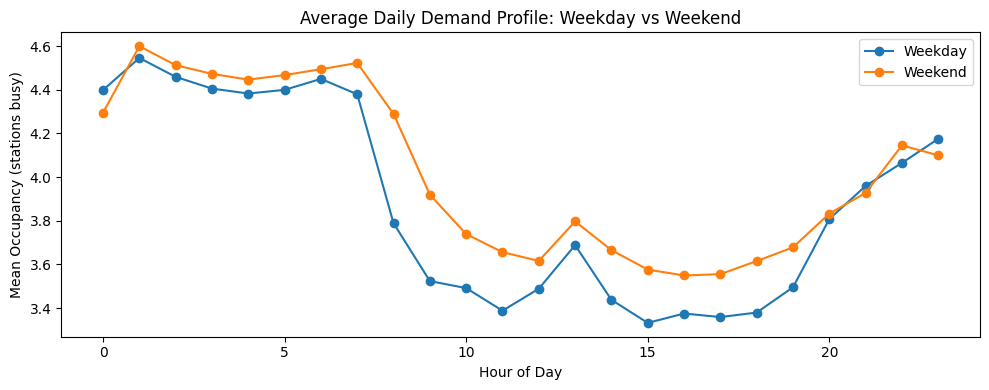

In [291]:
daily_profile = (
    occ_mean
    .groupby(['is_weekend', 'hour'])['average_occupancy']
    .mean()
    .unstack(0)
)

daily_profile.columns = ['Weekday', 'Weekend']

fig, ax = plt.subplots(figsize=(10, 4))
daily_profile.plot(ax=ax, marker='o')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Occupancy (stations busy)')
ax.set_title('Average Daily Demand Profile: Weekday vs Weekend')

plt.tight_layout()
#plt.savefig('weekday_vs_weekend.png', dpi=150)
plt.show()

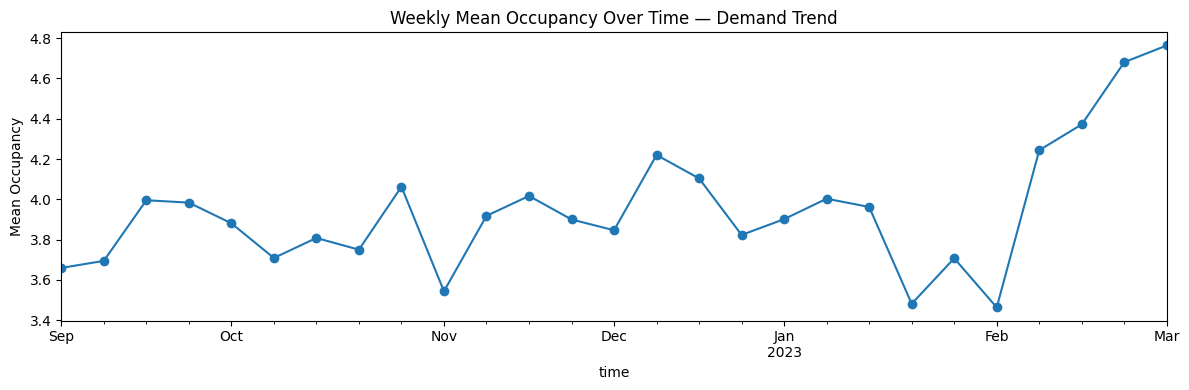

In [292]:
occ_weekly = data['occ'].copy()
occ_weekly['time'] = pd.to_datetime(occ_weekly['time'])
occ_weekly = occ_weekly.set_index('time')

weekly_mean = occ_weekly.mean(axis=1).resample('W').mean()
fig, ax = plt.subplots(figsize=(12, 4))
weekly_mean.plot(ax=ax, marker='o')

ax.set_title('Weekly Mean Occupancy Over Time — Demand Trend')
ax.set_ylabel('Mean Occupancy')

plt.tight_layout()
#plt.savefig('weekly_trend.png', dpi=150)
plt.show()

In [293]:
STATIONS=STATIONS[1:]

In [297]:
data['occ_rate'].isna().sum().sum()
data['occ_rate']['2125']=data['occ_rate']['2125'].fillna(0)

In [301]:
data['occ_rate']

,time,1001,1002,1003,1004,1005,1006,1007,1008,1009,...,2673,2674,2675,2676,2677,2678,2679,2680,2681,2682
0,2022-09-01 00:00:00,0.20,0.409091,0.333333,0.909091,0.454545,0.4,0.0,0.454545,0.500000,...,0.444444,0.25,0.4,0.555556,0.500000,0.000000,0.333333,0.166667,0.2,0.0
1,2022-09-01 01:00:00,0.35,0.272727,0.333333,0.545455,0.454545,0.7,0.0,0.431818,0.652778,...,0.694444,0.50,1.0,0.666667,0.583333,0.000000,0.250000,0.250000,0.3,0.0
2,2022-09-01 02:00:00,0.35,0.136364,0.166667,0.909091,0.454545,0.8,0.0,0.454545,0.833333,...,0.472222,0.25,0.0,0.555556,0.666667,0.000000,0.583333,0.250000,0.1,0.0
3,2022-09-01 03:00:00,0.40,0.136364,0.166667,0.909091,0.454545,0.8,0.0,0.454545,0.805556,...,0.472222,0.25,1.0,0.555556,0.666667,0.000000,0.583333,0.250000,0.1,0.0
4,2022-09-01 04:00:00,0.30,0.272727,0.333333,0.727273,0.454545,0.7,0.0,0.431818,0.750000,...,0.694444,0.50,1.0,0.555556,0.583333,0.000000,0.250000,0.250000,0.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4316,2023-02-27 20:00:00,0.35,0.318182,0.000000,0.727273,0.545455,0.3,0.6,0.681818,0.319444,...,0.277778,0.50,0.2,0.222222,0.416667,0.230769,0.250000,0.000000,0.1,0.0
4317,2023-02-27 21:00:00,0.35,0.318182,0.000000,0.727273,0.545455,0.3,0.6,0.681818,0.347222,...,0.250000,0.50,0.2,0.222222,0.416667,0.076923,0.250000,0.000000,0.1,0.0
4318,2023-02-27 22:00:00,0.35,0.318182,0.000000,0.727273,0.545455,0.7,0.6,0.681818,0.375000,...,0.305556,0.50,0.2,0.222222,0.416667,0.076923,0.250000,0.000000,0.1,0.0
4319,2023-02-27 23:00:00,0.35,0.318182,0.000000,0.727273,0.636364,0.9,0.6,0.681818,0.361111,...,0.305556,0.50,0.2,0.222222,0.416667,0.076923,0.250000,0.000000,0.1,0.0


In [302]:
data['occ_rate'] = data['occ_rate'].astype({col: 'int' for col in data['occ_rate'].columns if col != 'time'})

In [304]:
summary = pd.DataFrame(index=STATIONS)
summary['mean_util'] = data['occ_rate'].iloc[:, 1:].mean()
summary['peak_util'] = data['occ_rate'].iloc[:, 1:].max()
summary['pct_saturated'] = (data['occ_rate'].iloc[:, 1:] > 0.8).mean()
summary['mean_duration'] = data['dur'].iloc[:, 1:].mean()
summary['mean_volume'] = data['vol'].iloc[:, 1:].mean()
summary['cv'] = data['occ'].iloc[:, 1:].std() / data['occ'].iloc[:, 1:].mean()
summary = summary.join(data['inf'][['latitude', 'longitude', 'pile_count']])

In [305]:
summary

,mean_util,peak_util,pct_saturated,mean_duration,mean_volume,cv,latitude,longitude,pile_count
1001,0.128211,1,0.128211,0.845985,5.921893,0.609682,22.714121,113.784724,20
1002,0.246008,1,0.246008,0.957591,6.703136,0.700311,22.725900,113.785002,22
1003,0.001157,1,0.001157,0.160476,1.123332,1.753651,22.735538,113.787971,6
1004,0.036566,1,0.036566,4.615521,108.261822,0.366809,22.693449,113.788126,11
1005,0.000000,0,0.000000,3.802631,86.960445,0.302071,22.693449,113.788126,11
...,...,...,...,...,...,...,...,...,...
2678,0.000000,0,0.000000,0.155847,1.090932,3.565029,22.596409,114.478137,13
2679,0.000926,1,0.000926,2.040403,14.282824,0.667645,22.601834,114.481163,12
2680,0.041657,1,0.041657,0.178547,1.249826,1.704347,22.509882,114.483345,12
2681,0.034251,1,0.034251,0.364036,2.548253,0.896672,22.533926,114.493513,10


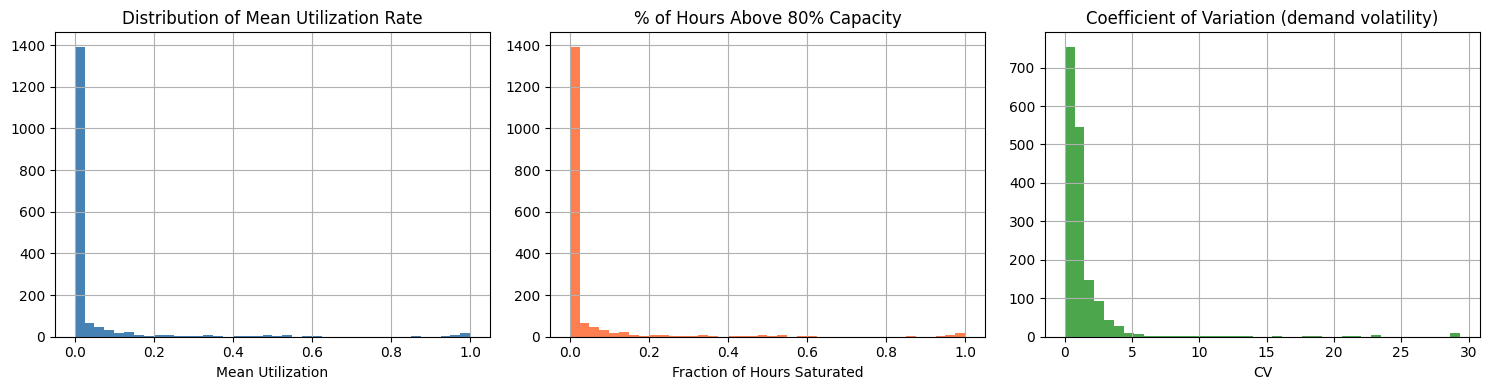

In [306]:
# --- Saturation risk distribution ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

summary['mean_util'].hist(bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Mean Utilization Rate')
axes[0].set_xlabel('Mean Utilization')

summary['pct_saturated'].hist(bins=40, ax=axes[1], color='coral')
axes[1].set_title('% of Hours Above 80% Capacity')
axes[1].set_xlabel('Fraction of Hours Saturated')

summary['cv'].hist(bins=40, ax=axes[2], color='green', alpha=0.7)
axes[2].set_title('Coefficient of Variation (demand volatility)')
axes[2].set_xlabel('CV')

plt.tight_layout()
#plt.savefig('station_distributions.png', dpi=150)
plt.show()

In [307]:
high_risk = summary[summary['pct_saturated'] > 0.3].sort_values('pct_saturated', ascending=False)
print(f"\nHigh saturation stations (>30% of hours above 80% capacity): {len(high_risk)}")
print(high_risk[['mean_util', 'pct_saturated', 'pile_count']].head(15))


High saturation stations (>30% of hours above 80% capacity): 77
      mean_util  pct_saturated  pile_count
2668   1.000000       1.000000           1
2095   1.000000       1.000000           3
2138   1.000000       1.000000          37
2514   1.000000       1.000000           3
1334   1.000000       1.000000           4
1630   0.988660       0.988660           2
1518   0.988660       0.988660           2
1335   0.988660       0.988660           3
2412   0.988660       0.988660           3
2309   0.987734       0.987734           4
2611   0.984263       0.984263          40
2193   0.980329       0.980329          28
1072   0.980329       0.980329          14
1581   0.980329       0.980329          18
1265   0.980329       0.980329          45


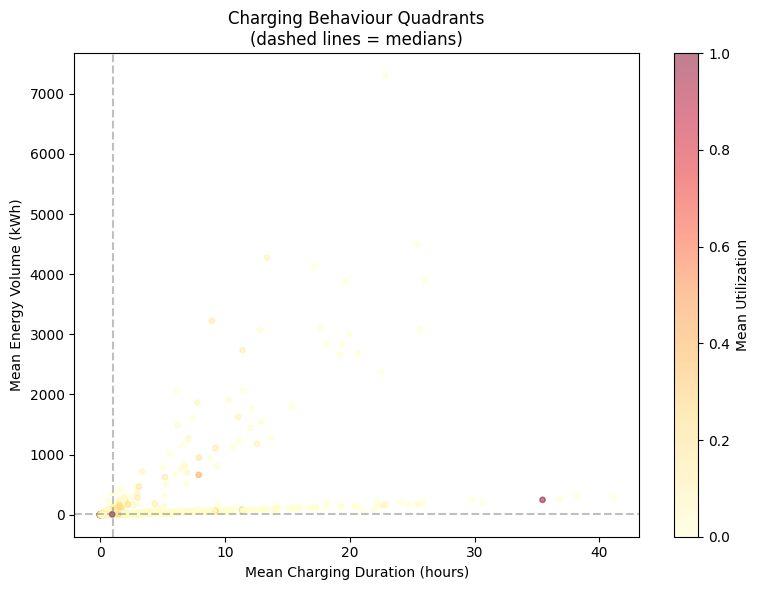

In [308]:
# --- Volume vs duration: charging behaviour quadrants ---
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    summary['mean_duration'],
    summary['mean_volume'],
    c=summary['mean_util'],
    cmap='YlOrRd',
    alpha=0.5,
    s=15
)
plt.colorbar(sc, ax=ax, label='Mean Utilization')
ax.axvline(summary['mean_duration'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(summary['mean_volume'].median(),   color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Mean Charging Duration (hours)')
ax.set_ylabel('Mean Energy Volume (kWh)')
ax.set_title('Charging Behaviour Quadrants\n(dashed lines = medians)')
plt.tight_layout()
#plt.savefig('charging_quadrants.png', dpi=150)
plt.show()

In [312]:
weather_occ = data['weather'].copy()
weather_occ['mean_occ'] = occ_mean['average_occupancy'].values

corr = weather_occ.corr()['mean_occ'].drop('mean_occ').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
corr.plot(kind='barh', ax=ax, color=['coral' if x < 0 else 'steelblue' for x in corr])
ax.set_title('Correlation of Weather Features with Mean Occupancy')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
#plt.savefig('weather_correlations.png', dpi=150)
plt.show()

ValueError: Length of values (4321) does not match length of index (8760)

In [310]:
weather_occ

,ap_T,ap_P,ap_U,ap_Ff,ap_Td,ap_wind_sin,ap_wind_cos,ap_is_raining,ap_cloud_cover,ap_visibility,...,ct_P,ct_U,ct_Ff,ct_Td,ct_wind_sin,ct_wind_cos,ct_is_raining,ct_cloud_cover,ct_visibility,mean_occ
time,,,,,,,,,,,,,,,,,,,,,
2022-09-01 00:00:00,28.0,756.2,89.0,2.0,26.0,0.000000e+00,1.000000e+00,0,0.0,10.0,...,759.7,77.0,2.0,20.2,0.382683,6.123234e-17,0.0,NaN,30.0,NaN
2022-09-01 01:00:00,29.0,756.2,84.0,1.0,26.0,1.224647e-16,-1.836970e-16,0,0.0,10.0,...,759.7,77.0,2.0,20.2,0.382683,6.123234e-17,0.0,NaN,30.0,NaN
2022-09-01 02:00:00,29.0,755.4,79.0,4.0,25.0,1.224647e-16,-1.836970e-16,0,2.0,10.0,...,756.1,87.0,1.0,24.9,-0.382683,9.238795e-01,0.0,NaN,27.0,NaN
2022-09-01 03:00:00,29.0,755.4,79.0,3.0,25.0,3.826834e-01,9.238795e-01,0,2.0,10.0,...,759.7,77.0,2.0,20.2,0.382683,6.123234e-17,0.0,NaN,30.0,NaN
2022-09-01 04:00:00,28.0,755.4,84.0,2.0,25.0,1.224647e-16,-1.836970e-16,0,0.0,10.0,...,759.7,77.0,2.0,20.2,0.382683,6.123234e-17,0.0,NaN,30.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-31 19:00:00,27.0,752.3,94.0,5.0,26.0,9.238795e-01,3.826834e-01,1,1.0,4.0,...,759.7,77.0,2.0,20.2,0.382683,6.123234e-17,0.0,NaN,30.0,NaN
2023-08-31 20:00:00,28.0,752.3,89.0,1.0,26.0,1.224647e-16,-1.836970e-16,0,1.0,10.0,...,752.3,72.0,2.0,23.6,0.000000,1.000000e+00,0.0,NaN,30.0,NaN
2023-08-31 21:00:00,28.0,752.3,84.0,2.0,25.0,-3.826834e-01,9.238795e-01,0,2.0,10.0,...,759.7,77.0,2.0,20.2,0.382683,6.123234e-17,0.0,NaN,30.0,NaN


In [311]:
occ_mean

,average_occupancy,time,hour,dow,is_weekend
0,4.195717,2022-09-01 00:00:00,0,3,0
1,4.412255,2022-09-01 01:00:00,1,3,0
2,4.693040,2022-09-01 02:00:00,2,3,0
3,4.602617,2022-09-01 03:00:00,3,3,0
4,4.319453,2022-09-01 04:00:00,4,3,0
...,...,...,...,...,...
4316,4.714456,2023-02-27 20:00:00,20,0,0
4317,4.841761,2023-02-27 21:00:00,21,0,0
4318,4.948840,2023-02-27 22:00:00,22,0,0
4319,5.042832,2023-02-27 23:00:00,23,0,0


In [315]:
w_airport.shape

(8760, 10)